In [3]:
import pandas as pd

# Load raw data, skip the messy header rows, data starts at row 5 (0-indexed)
raw = pd.read_excel("data/EN_ODP-TR-Study-IS_CITZ_sign_date (1).xlsx", header=None, skiprows=5)

# Build a clean table: Country + one "Total" column per year (2015-2025)
years = list(range(2015, 2026))
data = {"Country": raw[0]}

for i, year in enumerate(years):
    col_index = 17 + (i * 17)   # yearly total columns are spaced 17 apart
    data[year] = raw[col_index]

df = pd.DataFrame(data)

# Clean the numbers: remove commas, convert "--" (suppressed values) to 0
for year in years:
    df[year] = (
        df[year]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("--", "0")
        .replace("nan", "0")
        .astype(float)
    )

print(df.shape)
df.head(10)

(228, 12)


,Country,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Afghanistan,90.0,105.0,85.0,75.0,95.0,85.0,75.0,170.0,125.0,135.0,135.0
1,Albania,110.0,155.0,175.0,240.0,350.0,230.0,290.0,325.0,560.0,465.0,420.0
2,Algeria,960.0,800.0,965.0,1450.0,2640.0,2040.0,3030.0,5205.0,9330.0,9225.0,7645.0
3,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,0.0,0.0,5.0
4,Angola,65.0,75.0,35.0,30.0,120.0,30.0,50.0,75.0,70.0,70.0,95.0
5,Anguilla,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Antigua and Barbuda,65.0,75.0,95.0,90.0,75.0,45.0,80.0,70.0,85.0,40.0,45.0
7,Argentina,150.0,175.0,190.0,220.0,270.0,180.0,565.0,600.0,570.0,365.0,355.0
8,Armenia,15.0,30.0,20.0,20.0,20.0,10.0,45.0,60.0,70.0,90.0,95.0
9,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0


In [4]:
# Total study permits issued per year, across all countries
yearly_totals = df[years].sum()
print(yearly_totals)

2015     438115.0
2016     528615.0
2017     629940.0
2018     708485.0
2019     801120.0
2020     511055.0
2021     887010.0
2022    1095995.0
2023    1361395.0
2024    1029345.0
2025     761985.0
dtype: float64


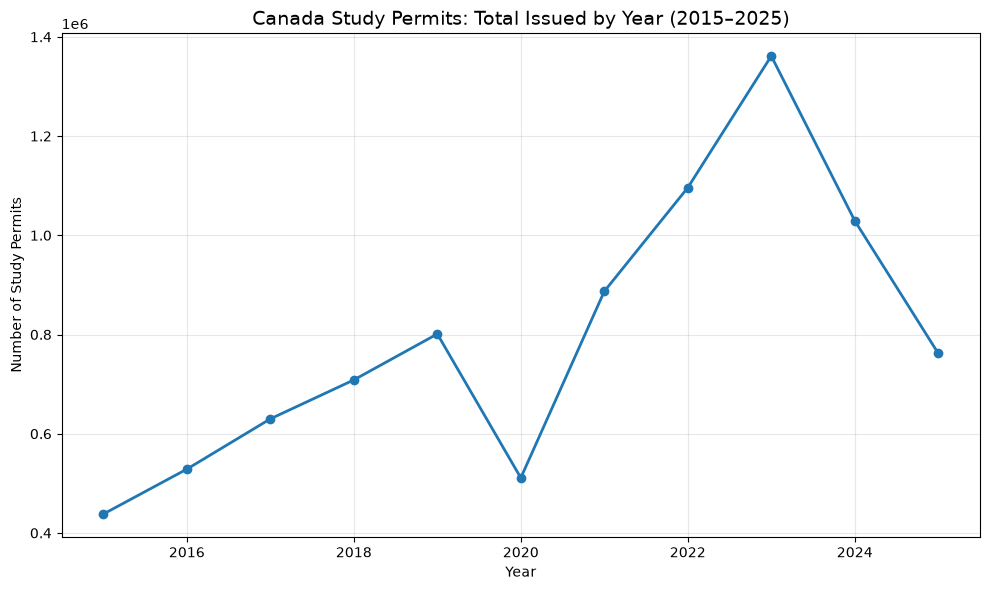

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years, yearly_totals.values, marker='o', linewidth=2, color='#1f77b4')
ax.set_title("Canada Study Permits: Total Issued by Year (2015–2025)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Study Permits")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs_peak_decline.png", dpi=150)
plt.show()

In [17]:
# Compare 2023 (peak year) to 2025 (most recent) by country
df['change_2023_to_2025'] = df[2025] - df[2023]
df['pct_change'] = ((df[2025] - df[2023]) / df[2023].replace(0, pd.NA)) * 100

# Top 10 countries by absolute drop in permits
top_declines = df.sort_values('change_2023_to_2025').head(10)
top_declines[['Country', 2023, 2025, 'change_2023_to_2025', 'pct_change']]

,Country,2023,2025,change_2023_to_2025,pct_change
220,Total unique persons,680690.0,381010.0,-299680.0,-44.025915
86,India,277950.0,93840.0,-184110.0,-66.238532
154,Philippines,33745.0,19855.0,-13890.0,-41.161654
142,Nigeria,37460.0,25370.0,-12090.0,-32.274426
135,Nepal,15885.0,5470.0,-10415.0,-65.564998
40,"China, People's Republic of",58005.0,48790.0,-9215.0,-15.886562
88,Iran,14725.0,9090.0,-5635.0,-38.268251
41,Colombia,10445.0,5775.0,-4670.0,-44.710388
27,Brazil,10360.0,6175.0,-4185.0,-40.395753
83,Hong Kong SAR,7855.0,3895.0,-3960.0,-50.413749


In [13]:
# Check for non-country summary rows
print(df['Country'].tail(10).tolist())

['Zimbabwe', 'Country of Citizenship not stated', 'Total unique persons', nan, nan, 'Notes: \n— Please note that all values between 0 and 5 are shown as “--”. This is done to prevent individuals from being identified when IRCC data is compiled and compared to other publicly available statistics. All other values are rounded to the closest multiple of 5 for the same reason; as a result of rounding, data may not sum to the totals indicated.\n— Data are preliminary estimates and are subject to change\n— The total unique count may not equal to the sum of permit holders in each program as an individual may hold more than one type of permit over a given period.\n— The table on Temporary Residents (TR) has been revised to reflect the June 20, 2014 overhaul of the Temporary Foreign Worker Program (TFWP). The reporting methodology has also been revised to count TRs, which includes Foreign Workers and International Students, based on the type of permit held by a TR (effective from the date that 

In [14]:
# Remove non-country rows: blanks, notes, and summary/total rows
junk_rows = [
    'Country of Citizenship not stated',
    'Total unique persons',
]

df_clean = df[~df['Country'].isin(junk_rows)]   # drop known junk labels
df_clean = df_clean.dropna(subset=['Country'])   # drop blank rows
df_clean = df_clean[~df_clean['Country'].astype(str).str.startswith('Notes')]  # drop footer notes

print(f"Before: {len(df)} rows")
print(f"After: {len(df_clean)} rows")
print(df_clean['Country'].tail(10).tolist())

Before: 228 rows
After: 221 rows
['Vanuatu', 'Venezuela', 'Vietnam', 'Virgin Islands, British', 'Western Sahara', 'Yemen', 'Zambia', 'Zimbabwe', 'For further information, please refer to the Facts and Figures 2015 – Immigration overview: Temporary residents overview, and the glossary of terms and concepts.', 'Source: IRCC, May 31, 2026']


In [18]:
top_declines = df_clean.sort_values('change_2023_to_2025').head(10)
top_declines[['Country', 2023, 2025, 'change_2023_to_2025', 'pct_change']]

,Country,2023,2025,change_2023_to_2025,pct_change
86,India,277950.0,93840.0,-184110.0,-66.238532
154,Philippines,33745.0,19855.0,-13890.0,-41.161654
142,Nigeria,37460.0,25370.0,-12090.0,-32.274426
135,Nepal,15885.0,5470.0,-10415.0,-65.564998
40,"China, People's Republic of",58005.0,48790.0,-9215.0,-15.886562
88,Iran,14725.0,9090.0,-5635.0,-38.268251
41,Colombia,10445.0,5775.0,-4670.0,-44.710388
27,Brazil,10360.0,6175.0,-4185.0,-40.395753
83,Hong Kong SAR,7855.0,3895.0,-3960.0,-50.413749
15,Bangladesh,9475.0,5540.0,-3935.0,-41.530343


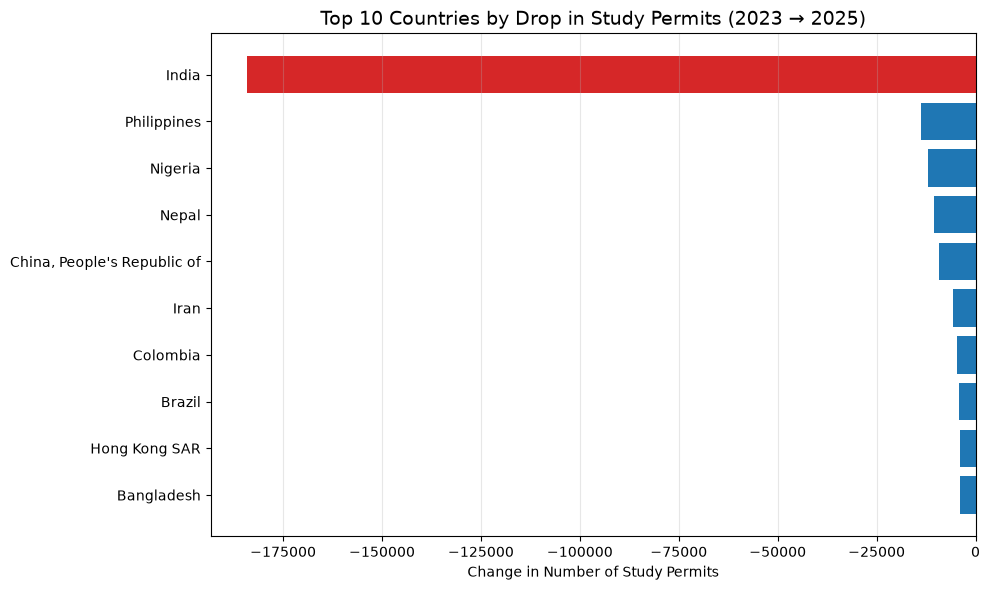

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if c == 'India' else '#1f77b4' for c in top_declines['Country']]
ax.barh(top_declines['Country'], top_declines['change_2023_to_2025'], color=colors)
ax.set_title("Top 10 Countries by Drop in Study Permits (2023 → 2025)", fontsize=14)
ax.set_xlabel("Change in Number of Study Permits")
ax.invert_yaxis()  # biggest decline at the top
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("outputs_top_declines.png", dpi=150)
plt.show()

## Key Findings

1. **Canada's international student intake peaked in 2023** at ~1.36 million study permits issued, then fell nearly 44% by 2025 (~762,000) — a decline steeper than the COVID-19 dip in 2020.

2. **India drove the majority of the decline.** Of the ~300,000 permit drop between 2023 and 2025, India alone accounts for -184,110 — about 61% of the total national decline. No other country comes close.

3. **The decline is broad, not isolated to one country.** Philippines, Nigeria, Nepal, and China also show meaningful drops, suggesting the policy changes (study permit caps introduced in 2024) affected demand across multiple major source countries, not just India.

## What likely explains this

- Canada introduced a national cap on new study permits starting in 2024, aimed at reducing temporary residents to below 5% of the population by 2027.
- Approval rates for study permit applications also fell sharply over this period, independent of the cap.
- India's outsized drop may reflect both the cap's effect and tightened scrutiny on specific visa/consultant pathways commonly used by Indian applicants.

## What I'd explore next with more time
- Break this down by province (Ontario was reportedly hit hardest — worth confirming with the province-level dataset)
- Separate "new" permits from "renewals" to see if the drop is about new arrivals or existing students leaving
- Compare public vs. private college enrolment, since colleges were reportedly hit harder than universities